# Slingshot — a quantitative teardown 🔬
### Gross-vs-net Sharpe · the cost wall & break-even · the horizon knife-edge · the holding-period rescue · the decay

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decayed since 2020?: Confirmed](https://img.shields.io/badge/Decayed_since_2020%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: cross-sectional short-term reversal is a real equity anomaly. We confirm it's `REAL` gross (Sharpe 0.70, +skew), show the daily turnover makes it a `MIRAGE` net (break-even 3.31 bp), and that it has `CONFIRMED` decayed — the exact equity mirror of Study 32's futures `NONE`.

> ⚠️ **Not investment advice.** The core executes on a synthetic OU-overshoot panel; the real S&P 500 run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md). The real panel is current-membership ⇒ survivorship bias; the reversal *sign* is robust, magnitudes are not.
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from slingshot import data, strategy, costs, extension

# Offline synthetic control: a panel with idiosyncratic OU overshoot (the machinery) + a random-walk null.
# The real S&P 500 verdict is in ../docs/results.md.
r, _, truth = data.synthetic_panel(revert_strength=0.06, seed=33)
r0, _, _ = data.synthetic_panel(revert_strength=0.0, seed=33)
print(f"synthetic control: {truth.n_stocks} stocks x {truth.n_bars} days, revert_strength {truth.revert_strength} (null=0)")


synthetic control: 150 stocks x 4032 days, revert_strength 0.06 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — reversal real in stocks? | 🟢 `REAL` | Gross Sharpe **0.70**, skew **+0.73**, market-neutral (futures: 0.08). |
| **Tradability** | 🔴 `MIRAGE` | Turnover **0.63**/day ⇒ break-even **3.31 bp**; net @5 bp **-0.36**. Premium concentrates in illiquid names. |
| **Decayed since 2020?** | ⚪ `Confirmed` | Net sub-period **-0.14/-0.04/-0.85**. |

> **In one sentence:** a real, market-neutral single-stock reversal premium that turns over 63% daily, hides in the costliest names, and has decayed — real to measure, a mirage to trade.

*(This notebook executes on the synthetic control; the real numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Each day, weight $w_{i,t} \propto -\big(x_{i,t}-\bar x_t\big)$ where $x_{i,t}$ is stock $i$'s trailing 5-day return and $\bar x_t$ the cross-sectional mean; weights are scaled so $\sum_i w_{i,t}=0$ (dollar-neutral) and $\sum_i|w_{i,t}|=1$ (gross 1), then executed on a **two-day lag** (shifted once at construction, once at execution) — conservative, since a faster fill could only help a reversal signal. Claim: $\sum_i w_{i,t-2} r_{i,t}$ earns a positive, market-neutral premium. Null: i.i.d. idiosyncratic returns ⇒ no cross-sectional overshoot to fade.

In [2]:
for label, rr in [('reverting panel', r), ('null', r0)]:
    g = strategy.summary(strategy.book_returns(rr, cost_bps=0.0))
    print(f"{label:16} gross Sharpe {g['sharpe']:+6.2f}  turnover/day {strategy.turnover(rr):.2f}")

reverting panel  gross Sharpe +10.00  turnover/day 0.68


null             gross Sharpe  -0.14  turnover/day 0.63


> 💡 **In plain words.** The control's stocks genuinely overshoot and drift back, so the book makes money gross (**10.0**); the null has none (**-0.14**). The apparatus sees reversal when it's there — so the real-tape result is about the *market*.

## Beat 2 · So what?

Lo–MacKinlay (1990) decompose contrarian profit into own- and cross-autocorrelation and a cross-sectional variance term; Nagel (2012) shows the payoff is the expected return on *providing liquidity*. The pre-registered prediction: the premium is real but lives where liquidity is scarce (single, smaller stocks) — so it should be biggest exactly where it costs the most to harvest. Beats 4–6 test that tension head-on.

## Beat 3 · Pre-registered protocol

1. **Real?** `book_returns(cost_bps=0)` on control vs null and on the real panel (gross).
2. **Tradable?** `strategy.turnover`, `costs.breakeven_cost_bps`, `costs.cost_sweep`.
3. **Decayed?** `extension.subperiod_sharpe`.
4. **Saveable?** `extension.holding_period_sweep` + `extension.lookback_sweep`.

**Mirage line:** break-even cost inside the ~2–10 bp realistic S&P round-trip band.

## Beat 4 · The teardown

### 4a · Real gross on the real tape (the REAL call)

In [3]:
print('Real tape (../docs/results.md):')
print('  reversal gross   Sharpe 0.70  CAGR 5.1%  maxDD -20%  skew +0.73')
print('  reversal net@5bp Sharpe -0.36   net@10bp Sharpe -1.42')
print('  -> a REAL premium; the futures mirror (Study 32) was only 0.08 gross')
print('\nSynthetic control gross Sharpe:', round(strategy.summary(strategy.book_returns(r, cost_bps=0.0))['sharpe'],1))

Real tape (../docs/results.md):
  reversal gross   Sharpe 0.70  CAGR 5.1%  maxDD -20%  skew +0.73
  reversal net@5bp Sharpe -0.36   net@10bp Sharpe -1.42
  -> a REAL premium; the futures mirror (Study 32) was only 0.08 gross



Synthetic control gross Sharpe: 10.0


> 💡 **In plain words.** 0.70 gross with positive skew, market-neutral, over 16 years and 467 names is not luck — it's a real effect. The fight is entirely about whether you can *keep* any of it after costs.

### 4b · The cost wall and the break-even (the MIRAGE call)

Real cost sweep (net Sharpe, ../docs/results.md):
  0bp 0.702   2bp 0.278   5bp -0.358   10bp -1.416   20bp -3.525
  turnover/day 0.63   break-even 3.31 bp  (avg S&P round-trip ~2-10 bp)



synthetic break-even: 12.75 bp


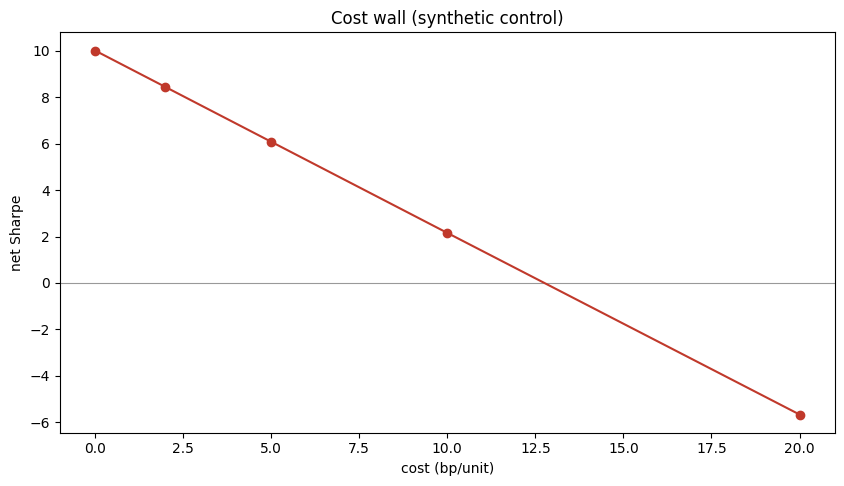

In [4]:
print('Real cost sweep (net Sharpe, ../docs/results.md):')
print('  0bp 0.702   2bp 0.278   5bp -0.358   10bp -1.416   20bp -3.525')
print(f'  turnover/day 0.63   break-even 3.31 bp  (avg S&P round-trip ~2-10 bp)')
cs = costs.cost_sweep(r)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net Sharpe'); ax.set_title('Cost wall (synthetic control)')
print('\nsynthetic break-even:', round(costs.breakeven_cost_bps(r), 2), 'bp')

## Beat 5 · The verdict

- **`REAL`** (4a): real gross Sharpe 0.70; control 10.0 vs null -0.14.
- **`MIRAGE`** (4b): break-even 3.31 bp inside the cost band; net @5 bp -0.36.
- **Decayed `CONFIRMED`** (Beat 7): net sub-period -0.14/-0.04/-0.85.

> **Signal `REAL` · Tradability `MIRAGE` · Decayed? `CONFIRMED`** — the equity mirror of Rip-Tide.

## Beat 6 · Could you trade it?

- **Not as shown.** Break-even 3.31 bp is inside the average S&P round-trip cost; smaller names cost more.
- **The reversal paradox** (Avramov–Chordia–Goyal 2006): the edge is largest in illiquid names and smallest in liquid ones — the only cheap-to-trade slice has almost no premium.
- **Capacity & decay:** even the liquid slice has shrunk as HFT entered (Khandani–Lo 2007); our most recent sub-period is the worst.

## Beat 7 · Going further

### 7a · Worked complement — the holding-period rescue ([`../docs/extension.md`](../docs/extension.md))
Hold each day's weights $h$ days to cut turnover; does the *net* Sharpe ever clear zero? Synthetic here; real tape in [`../docs/extension.md`](../docs/extension.md).

,gross_sharpe,net_sharpe,turnover_per_day
hold_days,,,
1,10.005,6.079,0.677
2,9.539,6.668,0.476
5,8.684,6.708,0.299
10,7.773,6.767,0.148
21,6.094,5.633,0.068


Real tape net Sharpe by hold (../docs/extension.md): 1d -0.36, 2d -0.00, 5d -0.11, 10d -0.14, 21d +0.10 -- just crosses zero at 21d.


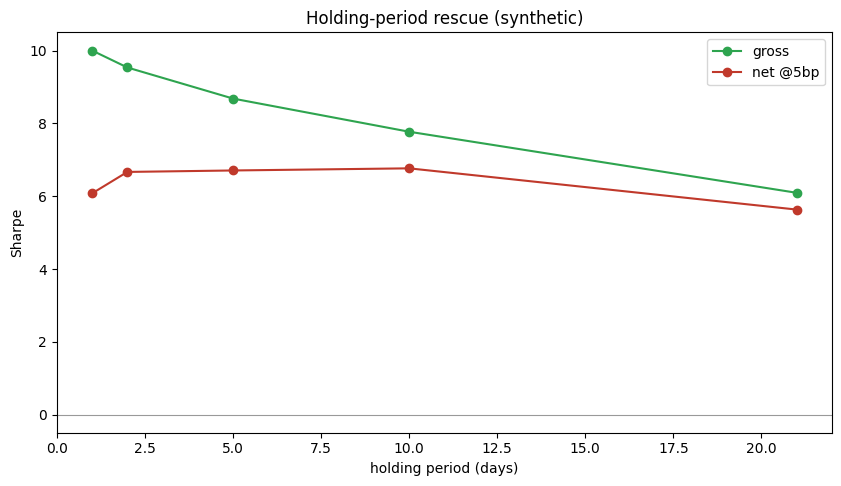

In [5]:
hp = extension.holding_period_sweep(r, holds=[1,2,5,10,21], cost_bps=5.0)
display(hp.round(3))
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(hp.index, hp['gross_sharpe'], marker='o', label='gross', color='#2ea44f')
ax.plot(hp.index, hp['net_sharpe'], marker='o', label='net @5bp', color='#c0392b')
ax.set_xlabel('holding period (days)'); ax.set_ylabel('Sharpe'); ax.legend(); ax.set_title('Holding-period rescue (synthetic)')
print('Real tape net Sharpe by hold (../docs/extension.md): '
      '1d -0.36, 2d -0.00, 5d -0.11, 10d -0.14, 21d +0.10 -- just crosses zero at 21d.')

> 💡 **In plain words.** Unlike Rip-Tide (rescue flatly busted), here slowing down *does* scrape a positive net Sharpe (+0.10 at 21 days) — because there really is a premium underneath. But +0.10 is within noise and below any hurdle. Real, not investable.

### 7b · The horizon knife-edge & the honest decay
The 1-day version is pure microstructure; the premium has faded in the modern era.

In [6]:
print('Real lookback sweep (net Sharpe @5bp, ../docs/results.md):')
print('  1d -2.38   3d -0.74   5d -0.36   10d -0.32   21d -0.19')
print('\nReal sub-period Sharpe (decay): -0.14 / -0.04 / -0.85 -- worst in 2020-2026.')
print('\nSynthetic lookback sweep (where the edge IS there):')
print(extension.lookback_sweep(r, lookbacks=[1,3,5,10,21]).round(2).to_string())

Real lookback sweep (net Sharpe @5bp, ../docs/results.md):
  1d -2.38   3d -0.74   5d -0.36   10d -0.32   21d -0.19

Real sub-period Sharpe (decay): -0.14 / -0.04 / -0.85 -- worst in 2020-2026.

Synthetic lookback sweep (where the edge IS there):


               sharpe   cagr
lookback_days               
1              -3.210 -0.070
3               3.300  0.070
5               6.080  0.140
10             10.310  0.250
21             13.800  0.370


**The result.** The apparatus captures reversal wherever it exists (control, every horizon) — and on the real S&P 500 it is `REAL` gross, `MIRAGE` net, and `CONFIRMED` decayed. Together with Study 32 (futures `NONE`), the pair localises short-term reversion to the single-stock, liquidity-provision cross-section. Full runs in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).

### 7c · Other forks
- **Liquidity-tiered book** — least-liquid quintile (biggest edge) with honest higher spreads.
- **Sector-neutralisation** — demean within GICS sector.
- **Crisis-conditional sizing** — trade only when dispersion/VIX is high (Nagel 2012).

PRs welcome — liquidity-tier it, sector-neutralise, or gate on dispersion.